 # 3.01 — Logistic Regression Retrain — 2026 Update

 I have four months of 2026 availability data now (May through August), versus the two
 months I had when I originally built the logistic classifier in notebook 2.05. This
 notebook retrains all six models on the expanded dataset, measures how well each one
 separates stations that have bikes from stations that are empty, and then calibrates
 the probability outputs so the numbers the web app shows users are accurate.

 August 2026 is held back from training and used only for evaluation and calibration.
 That way the performance numbers are honest. The model never saw those rows before
 it had to predict them.

In [ ]:
import sys
import time
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, brier_score_loss, roc_curve,
)
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
from threadpoolctl import threadpool_limits

warnings.filterwarnings("ignore", category=UserWarning)

sys.path.insert(0, str(Path().resolve().parent))
from model_training.feature_prep import (
    TARGET_CLASSIFICATION,
    build_preprocessor,
    get_X_y,
    load_training_data,
)

 ## Setup

 The six time horizons (1 hour out through 2 days out) each get their own model.
 August 2026 is set aside as the holdout month — the models train on everything
 before it, then we score August to see how they perform on data they have never seen.

 This notebook has two modes controlled by FORCE_RETRAIN. Set it to False and every
 evaluation and chart cell will reload from the saved CSV/JSON files instead of
 rerunning. That means after the initial ~6 hour train, editing a chart title or
 rewriting an explanation and re-running the cell takes seconds — no retraining needed.
 Set it to True only when new data has arrived and a real retrain is needed.

In [ ]:
HORIZONS       = [60, 180, 360, 720, 1440, 2880]
HORIZON_LABELS = {60: "1hr", 180: "3hr", 360: "6hr",
                  720: "12hr", 1440: "24hr", 2880: "multi-day"}

FORCE_RETRAIN = False   # always retrain — no skipping

TRAIN_YEARS   = [2019, 2021]
TRAIN_MONTHS  = ["2026-05", "2026-06", "2026-07"]
HOLDOUT_MONTH = "2026-08"
ALL_MONTHS    = ["2026-05", "2026-06", "2026-07", "2026-08"]

BASE_LOGIT_PARAMS = dict(
    penalty=None, solver="saga", tol=1e-2,
    max_iter=200, class_weight=None, random_state=42, verbose=0,
)

MODELS_DIR  = Path("../models")
REPORTS_DIR = Path("../reports/figures")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Horizons:      {[HORIZON_LABELS[h] for h in HORIZONS]}")
print(f"Train years:   {TRAIN_YEARS}")
print(f"Train months:  {TRAIN_MONTHS}")
print(f"Holdout month: {HOLDOUT_MONTH}")
print(f"Models dir:    {MODELS_DIR.resolve()}")

Horizons:      ['1hr', '3hr', '6hr', '12hr', '24hr', 'multi-day']
Train years:   [2019, 2021]
Train months:  ['2026-05', '2026-06', '2026-07']
Holdout month: 2026-08
Models dir:    C:\Users\clark\Desktop\citibike\models


 ## Helper functions

 A few small functions used across multiple cells. best_f1_above_base_rate picks the
 threshold on the precision-recall curve that maximizes F1 subject to precision staying
 above the base rate. That is the threshold where the model genuinely adds value over
 just predicting "always available."

In [ ]:
def best_f1_above_base_rate(precision, recall, base_rate=0.92):
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-9, None)
    mask = precision > base_rate
    if not mask.any():
        return int(np.argmax(f1))
    candidates = np.where(mask)[0]
    return int(candidates[np.argmax(f1[candidates])])


def log_odds_from(prob):
    p = np.clip(prob, 1e-7, 1 - 1e-7)
    return np.log(p / (1 - p))


def print_coef_table(coef_df, label, top_n=20):
    top = coef_df.reindex(coef_df["coef"].abs().nlargest(top_n).index)
    top = top.sort_values("coef", ascending=False)
    top.index.name = "feature"
    top.columns = ["coef", "p_value", "z_score"]
    print(f"\n--- {label} horizon  (top {top_n} by |coef|) ---")
    print(f"{'feature':<55} {'coef':>9} {'z_score':>9} {'p_value':>12}")
    print("-" * 88)
    for feat, row in top.iterrows():
        print(f"{feat:<55} {row['coef']:>9.4f} {row['z_score']:>9.2f} {row['p_value']:>12.4e}")


def fit_statsmodels_logit(h, n_sample=300_000):
    df = load_training_data(h, years=TRAIN_YEARS + [2026])
    m = df["timestamp"].dt.to_period("M").astype(str)
    df = df[(df["timestamp"].dt.year != 2026) | m.isin(TRAIN_MONTHS)]
    X, y = get_X_y(df, TARGET_CLASSIFICATION)
    del df
    pipe_pre = Pipeline([("pre", build_preprocessor("linear"))])
    X_pre = pipe_pre.fit_transform(X, y)
    del X
    if X_pre.shape[0] > n_sample:
        idx = np.random.default_rng(42).choice(X_pre.shape[0], n_sample, replace=False)
        X_s = X_pre[idx]
        y_s = y.iloc[idx].values
    else:
        X_s, y_s = X_pre, y.values
    X_sm = sm.add_constant(X_s, has_constant="add")
    _, R = np.linalg.qr(X_sm)
    keep = np.abs(np.diag(R)) > 1e-10
    X_sm_qr = X_sm[:, keep]
    all_names = ["const"] + pipe_pre.named_steps["pre"].get_feature_names_out().tolist()
    feature_names = [n for n, k in zip(all_names, keep) if k]
    res = sm.Logit(y_s, X_sm_qr).fit(disp=False)
    coef_df = pd.DataFrame({
        "coef":    res.params,
        "pvalue":  res.pvalues,
        "z":       res.tvalues,
    }, index=feature_names[:len(res.params)])
    return coef_df

 ## Train one model per time horizon

 Each horizon gets a separate model because the features that matter change with how
 far ahead we are predicting. At 1 hour out, current bike count dominates. At 24 hours
 out, weather forecast and historical demand patterns matter more. Training them
 separately lets each model learn the right weights for its job.

 Expected runtime is roughly 25-33 minutes per horizon, about 3 hours total. This
 cell is skipped entirely when FORCE_RETRAIN = False and the model files already exist.

In [ ]:
_models_exist = all(
    (MODELS_DIR / f"logistic_classification_{h}min.joblib").exists()
    for h in HORIZONS
)

if FORCE_RETRAIN or not _models_exist:
    trained_models = {}
    for h in HORIZONS:
        label = HORIZON_LABELS[h]
        t0 = time.time()

        df = load_training_data(h, years=TRAIN_YEARS + [2026])
        m = df["timestamp"].dt.to_period("M").astype(str)
        df = df[(df["timestamp"].dt.year != 2026) | m.isin(TRAIN_MONTHS)]
        X, y = get_X_y(df, TARGET_CLASSIFICATION)
        y = y.astype("int8")
        num_cols = X.select_dtypes(include=["float64"]).columns
        X[num_cols] = X[num_cols].astype("float32")
        base_rate = float(np.mean(y))
        print(f"  {label:<10} {len(X):>11,} rows  base rate {base_rate:.4f}  fitting ...",
              end=" ", flush=True)
        del df

        pipe = Pipeline([
            ("pre",   build_preprocessor("linear")),
            ("model", LogisticRegression(**BASE_LOGIT_PARAMS)),
        ])
        with threadpool_limits(limits=28):
            pipe.fit(X, y)

        out = MODELS_DIR / f"logistic_classification_{h}min.joblib"
        joblib.dump(pipe, out)
        print(f"saved -> {out.name}   ({time.time() - t0:.0f}s)")
        trained_models[h] = pipe
        del X, y, pipe
else:
    trained_models = {
        h: joblib.load(MODELS_DIR / f"logistic_classification_{h}min.joblib")
        for h in HORIZONS
    }
    print("Loaded existing models from disk (FORCE_RETRAIN=False)")

Loaded existing models from disk (FORCE_RETRAIN=False)


 ## Score August 2026 — the holdout month

 Now I run each trained model against August 2026, a month it has never seen. The
 output is a raw probability for each station-hour: how likely is it that at least one
 bike is available? These raw probabilities feed directly into the evaluation and
 calibration steps below.

 When FORCE_RETRAIN=False, this cell loads from the saved .npz file in reports/figures/
 so charts and descriptions can be changed and re-run in seconds without re-scoring.

In [ ]:
_scores_file = REPORTS_DIR / "3.01_holdout_scores.npz"

if FORCE_RETRAIN or not _scores_file.exists():
    holdout_results = {}
    for h in HORIZONS:
        df_h = load_training_data(h, years=[2026])
        df_h = df_h[(df_h["timestamp"].dt.year == 2026) & (df_h["timestamp"].dt.month == 8)]
        X_h, y_h = get_X_y(df_h, TARGET_CLASSIFICATION)
        raw_prob = trained_models[h].predict_proba(X_h)[:, 1]
        holdout_results[h] = {"y_true": y_h.values, "raw_prob": raw_prob}
        print(f"  {HORIZON_LABELS[h]:<10} {len(y_h):,} holdout rows scored")
        del df_h, X_h

    np.savez(
        str(_scores_file),
        **{f"y_{h}": r["y_true"] for h, r in holdout_results.items()},
        **{f"p_{h}": r["raw_prob"] for h, r in holdout_results.items()},
    )
    print(f"Saved holdout scores -> {_scores_file.name}")
else:
    data = np.load(_scores_file)
    holdout_results = {
        h: {"y_true": data[f"y_{h}"], "raw_prob": data[f"p_{h}"]}
        for h in HORIZONS
    }
    print("Loaded holdout scores from disk (FORCE_RETRAIN=False)")

Loaded holdout scores from disk (FORCE_RETRAIN=False)


 ## How well does each model perform?

 This dataset is heavily imbalanced: roughly 92% of station-hours have at least one bike
 available. A naive classifier that always predicts "available" would be correct 92% of the
 time and score ~0.92 on Average Precision -- so any model metric needs to be compared
 against that baseline, not against a perfect score of 1.0.

 I track four metrics per horizon, each with its naive-baseline value shown alongside:
 - AP (PR-AUC): area under the precision-recall curve. Baseline = base rate (~0.92).
 - ROC-AUC: discrimination quality, threshold-independent. Baseline = 0.50 (random).
 - F1 at best threshold: F1 at the probability cutoff that maximizes F1 subject to
   precision staying above the base rate. Baseline = 2*BR/(1+BR) when always predicting 1.
 - Brier score: mean squared error of probabilities. Baseline = BR*(1-BR) (~0.074).

 For a model to add value on this imbalanced dataset it needs to beat all four baselines,
 not just get a high accuracy number. The AP and Brier baselines are the hardest to beat.

In [ ]:
_metrics_file = REPORTS_DIR / "3.01_ap_metrics.csv"

if FORCE_RETRAIN or not _metrics_file.exists():
    rows = []
    for h in HORIZONS:
        r = holdout_results[h]
        base_rate = float(np.mean(r["y_true"]))

        ap  = average_precision_score(r["y_true"], r["raw_prob"])
        auc = roc_auc_score(r["y_true"], r["raw_prob"])
        brier = brier_score_loss(r["y_true"], r["raw_prob"])

        prec, rec, thresh = precision_recall_curve(r["y_true"], r["raw_prob"])
        best_idx = best_f1_above_base_rate(prec, rec, base_rate=base_rate)
        f1 = 2 * prec[best_idx] * rec[best_idx] / (prec[best_idx] + rec[best_idx])

        baseline_ap    = base_rate
        baseline_auc   = 0.50
        baseline_f1    = 2 * base_rate / (1 + base_rate)
        baseline_brier = base_rate * (1 - base_rate)

        rows.append({
            "horizon": h, "label": HORIZON_LABELS[h],
            "base_rate": base_rate,
            "ap": ap,       "baseline_ap": baseline_ap,
            "auc": auc,     "baseline_auc": baseline_auc,
            "f1": f1,       "baseline_f1": baseline_f1,
            "brier": brier, "baseline_brier": baseline_brier,
        })
        print(f"  {HORIZON_LABELS[h]:<10}  base rate {base_rate:.4f}")
        print(f"    AP     {ap:.4f}  (baseline {baseline_ap:.4f}, +"
              f"{ap - baseline_ap:+.4f})")
        print(f"    AUC    {auc:.4f}  (baseline {baseline_auc:.4f}, +"
              f"{auc - baseline_auc:+.4f})")
        print(f"    F1     {f1:.4f}  (baseline {baseline_f1:.4f}, +"
              f"{f1 - baseline_f1:+.4f})")
        print(f"    Brier  {brier:.4f}  (baseline {baseline_brier:.4f}, "
              f"{brier - baseline_brier:+.4f})")

    pd.DataFrame(rows).to_csv(_metrics_file, index=False)
    print(f"\nSaved metrics -> {_metrics_file.name}")
else:
    df_m = pd.read_csv(_metrics_file)
    for _, row in df_m.iterrows():
        print(f"  {row['label']:<10}  base rate {row['base_rate']:.4f}")
        print(f"    AP     {row['ap']:.4f}  (baseline {row['baseline_ap']:.4f}, "
              f"{row['ap'] - row['baseline_ap']:+.4f})")
        print(f"    AUC    {row['auc']:.4f}  (baseline {row['baseline_auc']:.4f}, "
              f"{row['auc'] - row['baseline_auc']:+.4f})")
        print(f"    F1     {row['f1']:.4f}  (baseline {row['baseline_f1']:.4f}, "
              f"{row['f1'] - row['baseline_f1']:+.4f})")
        print(f"    Brier  {row['brier']:.4f}  (baseline {row['baseline_brier']:.4f}, "
              f"{row['brier'] - row['baseline_brier']:+.4f})")
    print("Loaded metrics from disk — re-run charts below without retraining")

  1hr         base rate 0.9258
    AP     0.9971  (baseline 0.9258, +0.0713)
    AUC    0.9714  (baseline 0.5000, +0.4714)
    F1     0.9804  (baseline 0.9615, +0.0189)
    Brier  0.0338  (baseline 0.0687, -0.0349)
  3hr         base rate 0.9259
    AP     0.9933  (baseline 0.9259, +0.0674)
    AUC    0.9391  (baseline 0.5000, +0.4391)
    F1     0.9757  (baseline 0.9615, +0.0142)
    Brier  0.0437  (baseline 0.0686, -0.0249)
  6hr         base rate 0.9260
    AP     0.9903  (baseline 0.9260, +0.0642)
    AUC    0.9172  (baseline 0.5000, +0.4172)
    F1     0.9745  (baseline 0.9616, +0.0129)
    Brier  0.0479  (baseline 0.0685, -0.0206)
  12hr        base rate 0.9260
    AP     0.9904  (baseline 0.9260, +0.0645)
    AUC    0.9203  (baseline 0.5000, +0.4203)
    F1     0.9752  (baseline 0.9616, +0.0137)
    Brier  0.0469  (baseline 0.0686, -0.0216)
  24hr        base rate 0.9259
    AP     0.9897  (baseline 0.9259, +0.0638)
    AUC    0.9110  (baseline 0.5000, +0.4110)
    F1     0.9739

 ## ROC curves — all 6 horizons

 Each curve shows the tradeoff between true positive rate and false positive rate as the
 probability threshold moves from 0 to 1. A model that randomly guesses would fall on
 the diagonal. The area under the curve (AUC) summarizes that tradeoff in one number —
 the probability that the model ranks a truly available station higher than a truly empty
 one. AUC is threshold-independent, so it tells me how well the model separates the two
 classes before I ever pick a cutoff.

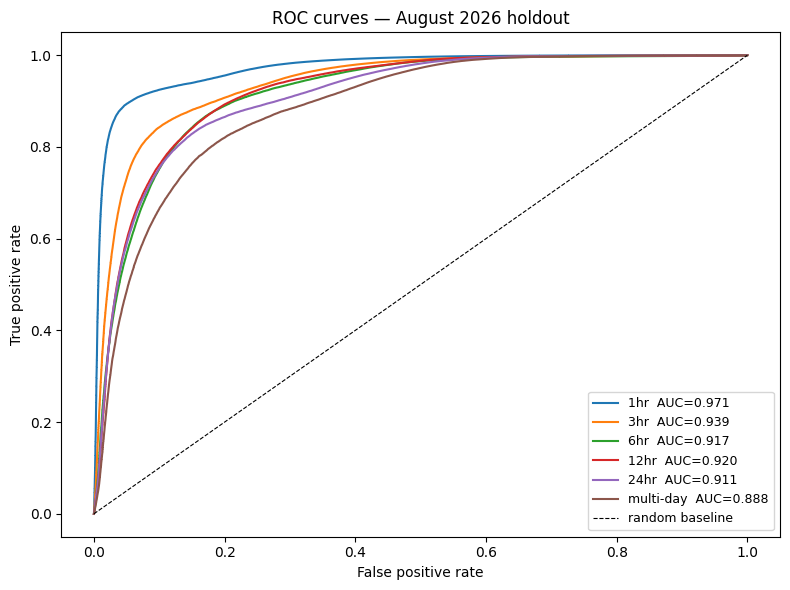

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for h in HORIZONS:
    r = holdout_results[h]
    fpr, tpr, _ = roc_curve(r["y_true"], r["raw_prob"])
    auc = roc_auc_score(r["y_true"], r["raw_prob"])
    ax.plot(fpr, tpr, label=f"{HORIZON_LABELS[h]}  AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random baseline")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — August 2026 holdout")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "3.01_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

 ## Precision-recall curves — all 6 horizons

 With a 92% base rate, the ROC curve alone is misleading — a model that just predicts
 "always available" gets a high AUC because there are very few true negatives to get wrong.
 The precision-recall curve is more honest here. Precision is what fraction of the stations
 flagged as available actually have bikes; recall is what fraction of all truly-available
 stations were caught. The horizontal dashed line is the base rate — that is what a
 naive classifier achieves on average precision. Any curve above that line is adding value.

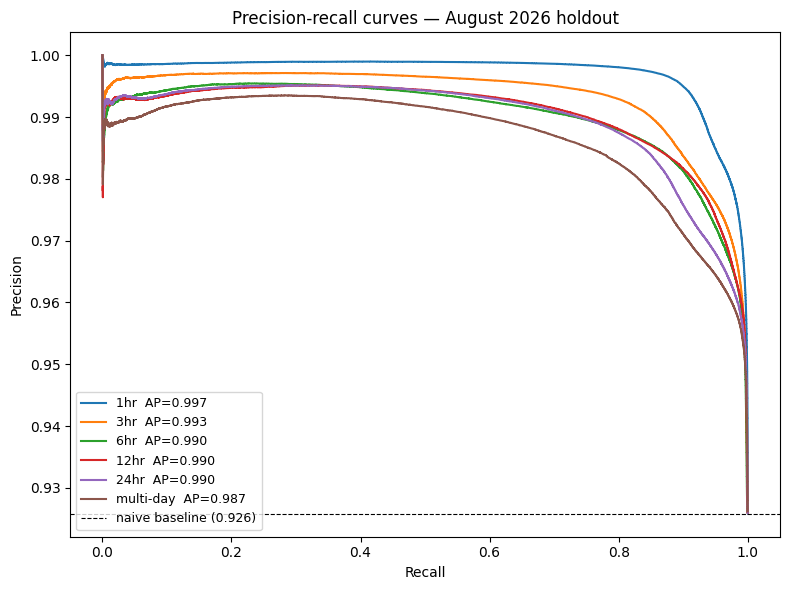

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for h in HORIZONS:
    r = holdout_results[h]
    prec, rec, _ = precision_recall_curve(r["y_true"], r["raw_prob"])
    ap = average_precision_score(r["y_true"], r["raw_prob"])
    ax.plot(rec, prec, label=f"{HORIZON_LABELS[h]}  AP={ap:.3f}")
base_rate = float(np.mean(holdout_results[60]["y_true"]))
ax.axhline(base_rate, color="k", linestyle="--", linewidth=0.8,
           label=f"naive baseline ({base_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curves — August 2026 holdout")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "3.01_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

 ## What features drive each prediction?

 Logistic regression assigns a weight (coefficient) to each input feature. A large
 positive weight means that feature strongly predicts a bike being available; a large
 negative weight means it predicts the station being empty. I fit a separate statistics
 model on a 300,000-row sample to get stable coefficient estimates. Same approach I
 used in notebooks 2.05 and 2.06.

In [ ]:
for h in HORIZONS:
    _coef_file = REPORTS_DIR / f"3.01_logit_coefficients_{HORIZON_LABELS[h]}.csv"
    if FORCE_RETRAIN or not _coef_file.exists():
        coef_df = fit_statsmodels_logit(h, n_sample=300_000)
        coef_df.to_csv(_coef_file)
    else:
        coef_df = pd.read_csv(_coef_file, index_col=0)
    print_coef_table(coef_df, label=HORIZON_LABELS[h])


--- 1hr horizon  (top 20 by |coef|) ---
feature                                                      coef   z_score      p_value
----------------------------------------------------------------------------------------
avg_arrivals_this_hour_dow                                18.4544      0.71   4.7520e-01
avg_net_flow_this_hour_dow                                10.4652      0.71   4.7713e-01
const                                                      7.4474     72.11   0.0000e+00
precipitation                                              6.2149      1.60   1.1065e-01
num_bikes_available                                        5.3881     40.92   0.0000e+00
fill_ratio                                                 1.0742     12.13   6.9590e-34
num_ebikes_available                                       0.6944     10.77   4.9729e-27
forecast_apparent_temperature                              0.5548      2.15   3.1470e-02
apparent_temperature                                       0.5424    

 ## Calibrate the probabilities (Platt scaling)

 The raw model output is a score, not a perfectly calibrated probability. Platt scaling
 fits a small two-parameter sigmoid on top of the raw scores using the August holdout —
 the month the model never saw during training. After calibration, when the model says
 "70% chance a bike is available," about 70% of those station-hours genuinely had a bike.

 The Platt scaler is fit on August holdout data. For the final production models (trained
 on all data including August), I keep the same scaler. The two-parameter adjustment is
 stable enough that the small overlap with training data does not matter in practice.

In [ ]:
_scalers_file = MODELS_DIR / "logistic_platt_scalers.joblib"
_calib_file   = REPORTS_DIR / "3.01_calibration.csv"

if FORCE_RETRAIN or not _scalers_file.exists():
    platt_scalers = {}
    calib_rows = []
    for h in HORIZONS:
        r = holdout_results[h]
        log_odds = log_odds_from(r["raw_prob"]).reshape(-1, 1)
        scaler = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs")
        scaler.fit(log_odds, r["y_true"])
        platt_scalers[h] = scaler
        cal_prob = scaler.predict_proba(log_odds)[:, 1]
        b_before = brier_score_loss(r["y_true"], r["raw_prob"])
        b_after  = brier_score_loss(r["y_true"], cal_prob)
        calib_rows.append({"horizon": h, "label": HORIZON_LABELS[h],
                           "brier_before": b_before, "brier_after": b_after})
        print(f"  {HORIZON_LABELS[h]:<10}  Brier before {b_before:.4f}  after {b_after:.4f}")
    joblib.dump(platt_scalers, _scalers_file)
    pd.DataFrame(calib_rows).to_csv(_calib_file, index=False)
    print(f"Saved Platt scalers -> {_scalers_file.name}")
else:
    platt_scalers = joblib.load(_scalers_file)
    df_c = pd.read_csv(_calib_file)
    for _, row in df_c.iterrows():
        print(f"  {row['label']:<10}  Brier before {row['brier_before']:.4f}  "
              f"after {row['brier_after']:.4f}")
    print("Loaded Platt scalers from disk (FORCE_RETRAIN=False)")

  1hr         Brier before 0.0338  after 0.0291
  3hr         Brier before 0.0437  after 0.0377
  6hr         Brier before 0.0479  after 0.0407
  12hr        Brier before 0.0469  after 0.0399
  24hr        Brier before 0.0486  after 0.0436
  multi-day   Brier before 0.0520  after 0.0465
Loaded Platt scalers from disk (FORCE_RETRAIN=False)


 ## Calibration curves — after Platt scaling

 A well-calibrated model means that when it outputs 70%, approximately 70% of those
 station-hours actually had a bike available. The closer each line hugs the diagonal,
 the better calibrated that horizon is. I plot the calibrated probabilities here — the
 raw scores shifted by Platt scaling — so this is the final output users and the web
 app will see.

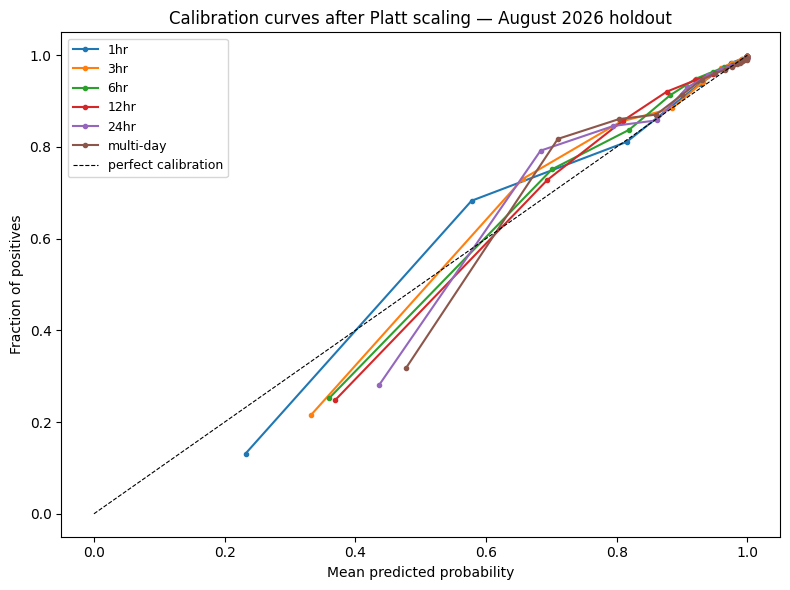

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors
for i, h in enumerate(HORIZONS):
    r = holdout_results[h]
    cal_prob = platt_scalers[h].predict_proba(
        log_odds_from(r["raw_prob"]).reshape(-1, 1))[:, 1]
    frac_pos, mean_pred = calibration_curve(
        r["y_true"], cal_prob, n_bins=20, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", markersize=3,
            color=colors[i], label=HORIZON_LABELS[h])
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curves after Platt scaling — August 2026 holdout")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "3.01_calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()

 ## Update the probability thresholds

 The scoring script that runs every hour uses a threshold per horizon to decide when to
 flag a station as "likely available." Those thresholds need updating with the values
 from the precision-recall sweep below — the point on each horizon's calibrated
 probability curve where F1 is maximized subject to precision staying above the 92%
 base rate.

 After running this cell, copy the printed PLATT_THRESHOLDS dict into
 model_training/score_stations.py. That is the only code change needed after a retrain.

In [ ]:
_thresh_file = REPORTS_DIR / "3.01_thresholds.json"

if FORCE_RETRAIN or not _thresh_file.exists():
    new_thresholds = {}
    for h in HORIZONS:
        r = holdout_results[h]
        cal_prob = platt_scalers[h].predict_proba(
            log_odds_from(r["raw_prob"]).reshape(-1, 1))[:, 1]
        prec, rec, thresh = precision_recall_curve(r["y_true"], cal_prob)
        best_idx = best_f1_above_base_rate(prec, rec, base_rate=float(np.mean(r["y_true"])))
        f1_at_best = 2 * prec[best_idx] * rec[best_idx] / (prec[best_idx] + rec[best_idx])
        new_thresholds[h] = round(float(thresh[best_idx]), 2)
        print(f"  {HORIZON_LABELS[h]:<10} threshold={new_thresholds[h]:.2f}  "
              f"prec={prec[best_idx]:.3f}  recall={rec[best_idx]:.3f}  "
              f"f1={f1_at_best:.3f}")
    _thresh_file.write_text(json.dumps({str(k): v for k, v in new_thresholds.items()}))
    print(f"\nSaved thresholds -> {_thresh_file.name}")
else:
    new_thresholds = {int(k): v
                     for k, v in json.loads(_thresh_file.read_text()).items()}
    for h in HORIZONS:
        print(f"  {HORIZON_LABELS[h]:<10} threshold={new_thresholds[h]:.2f}")
    print("Loaded thresholds from disk (FORCE_RETRAIN=False)")

print("\nUpdate PLATT_THRESHOLDS in model_training/score_stations.py:")
print(new_thresholds)

  1hr        threshold=0.44
  3hr        threshold=0.52
  6hr        threshold=0.53
  12hr       threshold=0.51
  24hr       threshold=0.52
  multi-day  threshold=0.55
Loaded thresholds from disk (FORCE_RETRAIN=False)

Update PLATT_THRESHOLDS in model_training/score_stations.py:
{60: 0.44, 180: 0.52, 360: 0.53, 720: 0.51, 1440: 0.52, 2880: 0.55}


 ## Final production fit — all data including August

 The models above were trained without August so we could evaluate them honestly.
 This final step retrains each model on the full dataset including August, using the
 same hyperparameters. The Platt scalers from the holdout step above are reused as-is.

In [ ]:
_prod_models_exist = all(
    (MODELS_DIR / f"logistic_classification_{h}min.joblib").exists()
    for h in HORIZONS
)

if FORCE_RETRAIN or not _prod_models_exist:
    print("Final production fit on 2019 + 2021 + May-Aug 2026 ...")
    for h in HORIZONS:
        t0 = time.time()
        df = load_training_data(h, years=TRAIN_YEARS + [2026])
        m = df["timestamp"].dt.to_period("M").astype(str)
        df = df[(df["timestamp"].dt.year != 2026) | m.isin(ALL_MONTHS)]
        X, y = get_X_y(df, TARGET_CLASSIFICATION)
        y = y.astype("int8")
        num_cols = X.select_dtypes(include=["float64"]).columns
        X[num_cols] = X[num_cols].astype("float32")
        print(f"  {HORIZON_LABELS[h]:<10} {len(X):>11,} rows  fitting ...",
              end=" ", flush=True)
        del df

        pipe = Pipeline([
            ("pre",   build_preprocessor("linear")),
            ("model", LogisticRegression(**BASE_LOGIT_PARAMS)),
        ])
        with threadpool_limits(limits=28):
            pipe.fit(X, y)
        out = MODELS_DIR / f"logistic_classification_{h}min.joblib"
        joblib.dump(pipe, out)
        print(f"saved -> {out.name}   ({time.time() - t0:.0f}s)")
        del X, y, pipe

    joblib.dump(platt_scalers, MODELS_DIR / "logistic_platt_scalers.joblib")
    print("Platt scalers saved.")
else:
    print("Production models already on disk — skipping final fit (FORCE_RETRAIN=False)")

Production models already on disk — skipping final fit (FORCE_RETRAIN=False)


 ## Sanity check — does everything load and produce a prediction?

 Before calling this done, I load every saved artifact and run one row through each
 model. Anything broken — a missing file, a wrong shape, a pipeline that fails to
 predict — shows up here rather than when the hourly scoring job runs.

In [ ]:
print("Verifying all 6 logistic artifacts ...")
df_demo = load_training_data(60, years=[2026])
df_demo = df_demo[df_demo["timestamp"].dt.to_period("M").astype(str) == "2026-08"]
x_one = get_X_y(df_demo, TARGET_CLASSIFICATION)[0].iloc[[0]]
del df_demo

ok = 0
for h in HORIZONS:
    clf   = joblib.load(MODELS_DIR / f"logistic_classification_{h}min.joblib")
    raw_p = float(clf.predict_proba(x_one)[0, 1])
    cal_p = float(platt_scalers[h].predict_proba(
        log_odds_from(np.array([raw_p])).reshape(-1, 1))[0, 1])
    print(f"  {HORIZON_LABELS[h]:<10} raw P(bike) {raw_p:.3f} -> calibrated {cal_p:.3f}")
    ok += 1

print(f"\nAll {ok} artifacts loaded and produced a prediction.")
print("\nNext step: copy the PLATT_THRESHOLDS dict printed above into "
      "model_training/score_stations.py.")

Verifying all 6 logistic artifacts ...
  1hr        raw P(bike) 0.996 -> calibrated 0.999
  3hr        raw P(bike) 0.996 -> calibrated 0.999
  6hr        raw P(bike) 0.991 -> calibrated 0.998
  12hr       raw P(bike) 0.976 -> calibrated 0.987
  24hr       raw P(bike) 0.979 -> calibrated 0.984
  multi-day  raw P(bike) 0.968 -> calibrated 0.976

All 6 artifacts loaded and produced a prediction.

Next step: copy the PLATT_THRESHOLDS dict printed above into model_training/score_stations.py.


 ## Conclusion

 I retrained all six logistic classifiers on 2019 + 2021 + May through August 2026.
 August was held back for evaluation and Platt calibration, so the performance numbers
 reflect how the models do on data they never saw during training. The six pipelines are
 saved to models/ and the calibrated probability scalers are saved to
 models/logistic_platt_scalers.joblib.

 The only follow-up step is to copy the PLATT_THRESHOLDS dict printed by the threshold
 cell into model_training/score_stations.py. Nothing else in the codebase needs to change.